## Senior Project - ML Models (Decision Tree and Random Forest) for Home Valuation

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Read in the data
file_path = 'data/SLO_House_Price_ZipCode.xlsx'
df = pd.read_excel(file_path , usecols = 'A:CP')
df.head()

,...1,...2,CITY,Listing.ID,S,House_Type,D_A,St_Number,St_Name,Area,...,road,town,county,state,ISO3166-2-lvl4,postcode,country,country_code,boundingbox,building
0,1,1,Arroyo Grande,PI21270563,S,SFR,D,103,Quail Ridge CT,AGEH,...,Quail Ridge Court,Arroyo Grande,San Luis Obispo County,California,US-CA,93420.0,United States,us,"c(""35.1349533"", ""35.1351951"", ""-120.5815660"", ...",NaN
1,3,3,Arroyo Grande,PI22042349,S,MANL,D,6530,Chanterelle LN,AGEH,...,East Grand Avenue,Arroyo Grande,San Luis Obispo County,California,US-CA,93420.0,United States,us,"c(""35.1184597"", ""35.1187301"", ""-120.5910113"", ...",Grand Barbers
2,5,5,Arroyo Grande,PI22008582,S,SFR,D,1775,Calle Pacifico,AGWH,...,East Grand Avenue,Arroyo Grande,San Luis Obispo County,California,US-CA,93420.0,United States,us,"c(""35.1184597"", ""35.1187301"", ""-120.5910113"", ...",Grand Barbers
3,11,11,Arroyo Grande,PI22053512,S,SFR,D,739,Avocet WAY,AGME,...,Avocet Way,Arroyo Grande,San Luis Obispo County,California,US-CA,93420.0,United States,us,"c(""35.0683198"", ""35.0686051"", ""-120.5742939"", ...",NaN
4,12,12,Arroyo Grande,PI22045118,S,SFR,D,923,Cameron CT,AGWH,...,Cameron Court,Arroyo Grande,San Luis Obispo County,California,US-CA,93445.0,United States,us,"c(""35.1086660"", ""35.1088447"", ""-120.5926143"", ...",NaN


In [3]:
print(df.columns)

Index(['...1', '...2', 'CITY', 'Listing.ID', 'S', 'House_Type', 'D_A',
       'St_Number', 'St_Name', 'Area', 'SLC', 'Price', 'SQFT_Price', 'Br.Ba',
       'Bedrooms', 'Ba_Full', 'Ba3_4', 'Ba_Half', 'Bath_1_4', 'Sqft',
       'Home_Size', 'Suffix', 'Year_Built', 'Build_Type', 'Lot_Size',
       'Lot_Acres', 'Pool.Private.YN', 'Garage.Spaces',
       'Contract.Status.Change.Date', 'DOM.CDOM', 'Year', 'observation_date',
       'ATNHPIUS06079A', 'HPI', 'Adjustment_Factor', 'Adjusted_Price',
       'full_address', 'Latitude', 'Longitude', 'SLO', 'Avg_High_Temp',
       'Avg_Low_Temp', 'geometry', 'dist_closest_highschool',
       'dist_closest_middleschool', 'dist_closest_elementary',
       'violent_crime_rate', 'property_crime_rate', 'total_crime_rate',
       'distance_to_coast', 'dist_downtown', 'dist_calpoly', 'nearest_high',
       'dist_closest_middle', 'nearest_middle', 'nearest_elementary', 'sold',
       'Age', 'CITY_Paso_Robles', 'CITY_SLO', 'CITY_Atascadero',
       'CITY_Arro

In [ ]:
df.columns

In [ ]:
# Drop the unneccessary columns
df = df.drop(['...1', '...2'], axis=1)

In [ ]:
for value in df:
    print('For {},{} unique values present'.format(value,df[value].nunique()))

In [ ]:
# DONT DO THIS - IT WILL MAKE THE DATA LIKE 281 VARS
# Drop rows with missing values
#df.dropna(inplace=True)

In [ ]:
target = 'Adjusted_Price'
# features.
features = [col for col in data.columns if col != target]

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' contains the data
adjusted_price = df['Adjusted_Price']

# Calculate the median
median_price = adjusted_price.median()

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(adjusted_price, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(median_price, color='red', linestyle='dashed', linewidth=2, label=f'Median Price: ${median_price:,.2f}')
plt.title('Distribution of Adjusted Price', fontsize=14, weight='bold')
plt.xlabel('Adjusted Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.75)
plt.show()


In [ ]:
# Assuming 'df' contains the data and the column 'Adjusted_Price'
import pandas as pd

# Filter out the top 5% of Adjusted_Price
filtered_df = df[df['Adjusted_Price'] <= df['Adjusted_Price'].quantile(0.95)]
adjusted_price_filtered = filtered_df['Adjusted_Price']

# Calculate the median of the filtered data
median_price_filtered = adjusted_price_filtered.median()

# Plot the distribution of the filtered data
plt.figure(figsize=(10, 6))
plt.hist(adjusted_price_filtered, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(median_price_filtered, color='red', linestyle='dashed', linewidth=2, label=f'Median Price: ${median_price_filtered:,.2f}')
plt.title('Distribution of Adjusted Price (Top 5% Excluded)', fontsize=14, weight='bold')
plt.xlabel('Adjusted Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.75)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size and plotting context
plt.figure(figsize=(10, 6))
sns.set_context('notebook', font_scale=1.2)

# Generate a pairplot with specific columns and hue
g = sns.pairplot(df[['Home_Size', 'Lot_Size', 'Adjusted_Price', 'Ba_Full', 'Bedrooms', 'Pool.Private.YN', 'Age', 'Garage.Spaces']],
                 hue='Bedrooms', height=2)

# Remove x-axis tick labels
g.set(xticklabels=[])


In [ ]:
sns.jointplot(x='Home_Size',y='Adjusted_Price',data=df,kind='reg',size=4)
sns.jointplot(x='Lot_Size',y='Adjusted_Price',data=df,kind='reg',size=4)
sns.jointplot(x='Bedrooms',y='Adjusted_Price',data=df,kind='reg',size=4)
sns.jointplot(x='Age',y='Adjusted_Price',data=df,kind='reg',size=4)

C:\Users\matin\AppData\Local\Temp\ipykernel_25572\3107032189.py:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df[heatmap_columns].corr()


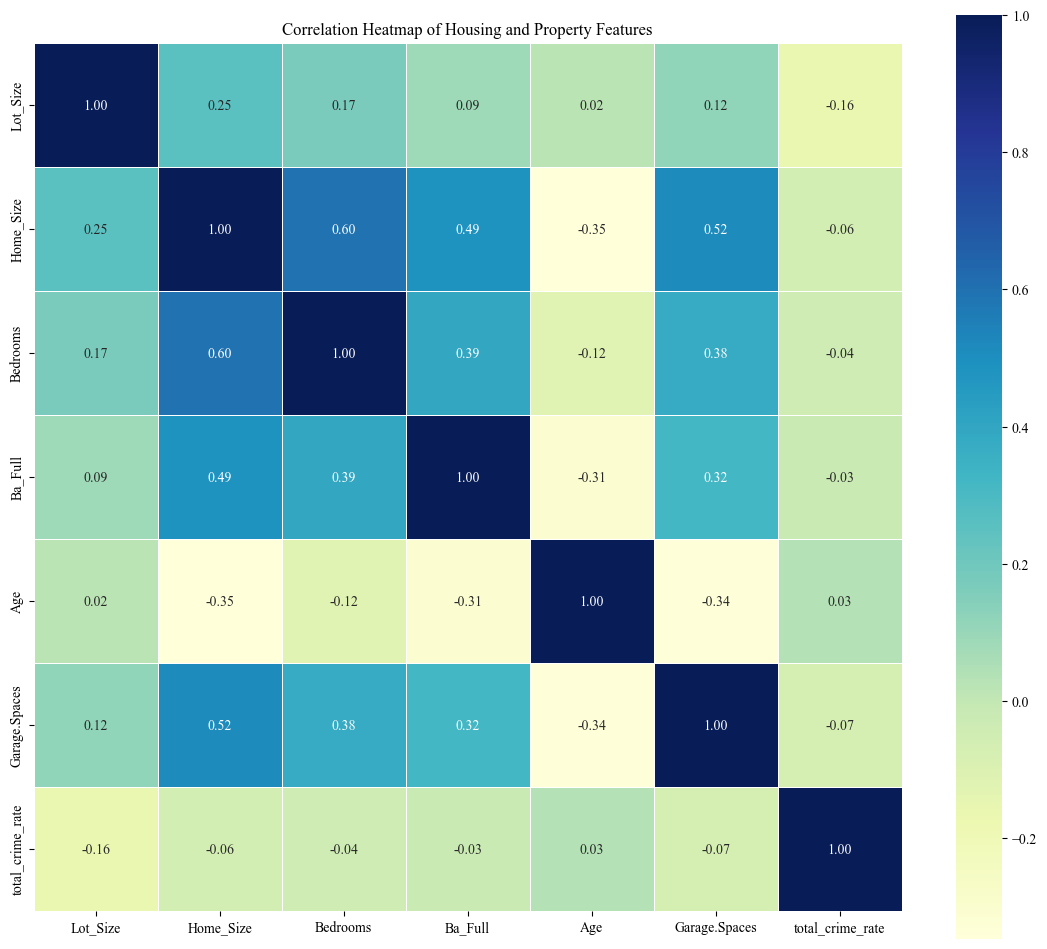

In [12]:
# Select columns for the heatmap, excluding temperature and distance-related features
heatmap_columns = [
    'Lot_Size', 'Home_Size', 'Bedrooms', 'Ba_Full', 'Age', 'Pool.Private.YN', 'Garage.Spaces', 'total_crime_rate'
]

# Calculate the correlation matrix
corr_matrix = df[heatmap_columns].corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 12))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", square=True, linewidths=.5, fmt=".2f")

# Display the heatmap
plt.title("Correlation Heatmap of Housing and Property Features")
plt.show()

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import explained_variance_score
from sklearn.metrics import confusion_matrix

# Split the Data


### Change Postcode into categroical variable

In [13]:
# Convert postcode to a string (categorical format)
df['postcode'] = df['postcode'].astype(str)

In [14]:
from sklearn.preprocessing import LabelEncoder
# Option 1: One-Hot Encoding (creates new columns for each unique postcode)


In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Define the variables to filter (excluding postcode)
variables_to_filter = ['Lot_Size', 'Home_Size', 'Bedrooms', 'Ba_Full', 'Age', 
                       'Garage.Spaces', 'total_crime_rate']

# Calculate the 95th percentile for each variable and filter the DataFrame
for var in variables_to_filter:
    upper_threshold = df[var].quantile(0.95)
    df = df[df[var] <= upper_threshold]

# Define features (X) and target (y)
X = df[['Lot_Size', 'Home_Size', 'Bedrooms', 'Ba_Full', 'Age', 'Pool.Private.YN', 
        'Garage.Spaces', 'total_crime_rate', 'postcode']]
y = df['Adjusted_Price']

# Convert categorical variables to numerical (one-hot encoding)
X = pd.get_dummies(X, columns=['Pool.Private.YN', 'postcode'], drop_first=True)
X = X.fillna(X.mean())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [16]:
# Define features (X) and target (y)

# Calculate Q1 (25th percentile) and Q3 (75th percentile) of the target variable (price)
Q1 = df['Adjusted_Price'].quantile(0.25)
Q3 = df['Adjusted_Price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to exclude outliers in price
df_filtered = df[(df['Adjusted_Price'] >= lower_bound) & (df['Adjusted_Price'] <= upper_bound)]
#df_filtered['Log_Adjusted_Price'] = np.log(df_filtered['Adjusted_Price'])


X = df_filtered[['Lot_Size', 'Home_Size', 'Bedrooms','Ba_Full', 'Age', 'Pool.Private.YN', 'Garage.Spaces', 'total_crime_rate', 'postcode']]
y = df_filtered['Adjusted_Price']

# Convert categorical variables to numerical (one-hot encoding)
X = pd.get_dummies(X, columns=['Pool.Private.YN', 'postcode'], drop_first=True)
X = X.fillna(X.mean())

#y = np.log(y)


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

C:\Users\matin\AppData\Local\Temp\ipykernel_25572\795357923.py:32: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = summary_table.to_latex(


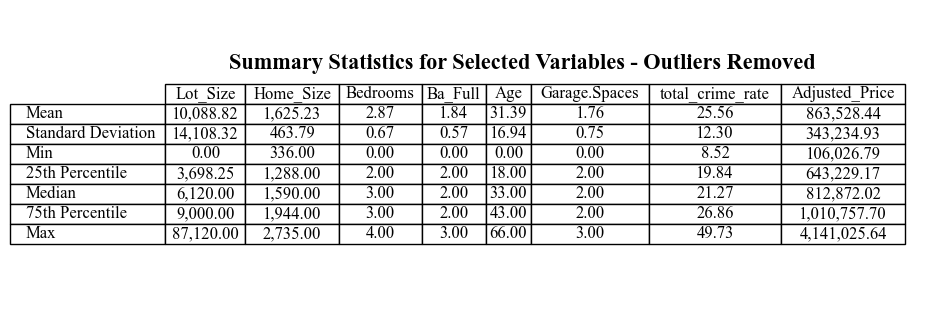

LaTeX table saved as summary_stats_table.tex


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configure global font to Times New Roman for professionalism
rcParams["font.family"] = "Times New Roman"

# Create a function to generate summary statistics
def generate_summary_table(X, y, visualize=False):
    # Combine X and y for summary statistics
    data = pd.concat([X, y.rename('Adjusted_Price')], axis=1)
    
    # Select only numeric columns for summary statistics
    numeric_data = data.select_dtypes(include=[np.number])

    # Define the summary statistics
    summary_stats = {
        'Mean': numeric_data.mean().apply(lambda x: f"{x:,.2f}"),
        'Standard Deviation': numeric_data.std().apply(lambda x: f"{x:,.2f}"),
        'Min': numeric_data.min().apply(lambda x: f"{x:,.2f}"),
        '25th Percentile': numeric_data.quantile(0.25).apply(lambda x: f"{x:,.2f}"),
        'Median': numeric_data.median().apply(lambda x: f"{x:,.2f}"),
        '75th Percentile': numeric_data.quantile(0.75).apply(lambda x: f"{x:,.2f}"),
        'Max': numeric_data.max().apply(lambda x: f"{x:,.2f}")
    }

    # Transpose the summary table to have variables as columns
    summary_table = pd.DataFrame(summary_stats).T

    # Add professional styling for LaTeX
    latex_table = summary_table.to_latex(
        escape=False,
        caption="\textbf{Summary Statistics for Selected Variables}",
        label="tab:summary_stats",
        column_format="|l|" + "|c|" * len(summary_table.columns)
    )

    # Enhance visualization with professional style if visualize=True
    if visualize:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.axis('tight')
        ax.axis('off')
        table = ax.table(
            cellText=summary_table.values,
            colLabels=summary_table.columns,
            rowLabels=summary_table.index,
            loc='center',
            cellLoc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(12)
        table.auto_set_column_width(col=list(range(len(summary_table.columns))))
        table.scale(1.2, 1.2)
        
        fig.suptitle("Summary Statistics for Selected Variables - Outliers Removed", fontsize=16, weight='bold', y=0.77)
        plt.show()

    return latex_table

# Example usage
# Exclude 'postcode' as it is not numeric
table_X = df[['Lot_Size', 'Home_Size', 'Bedrooms', 'Ba_Full', 'Age', 'Pool.Private.YN', 'Garage.Spaces', 'total_crime_rate']]
table_y = df['Adjusted_Price']

latex_table = generate_summary_table(X=table_X, y=table_y, visualize=True)

# Save the LaTeX table to a file
with open("summary_stats_table.tex", "w") as file:
    file.write(latex_table)

print("LaTeX table saved as summary_stats_table.tex")


## Multiple Linear Regressio:

In [18]:
mlr = LinearRegression()
mlr.fit(X_train,y_train)
mlr_score = mlr.score(X_test,y_test)
pred_mlr = mlr.predict(X_test)
expl_mlr = explained_variance_score(pred_mlr,y_test)

### Decision Tree Model

In [19]:
tr_regressor = DecisionTreeRegressor(random_state=0)
tr_regressor.fit(X_train,y_train)
tr_regressor.score(X_test,y_test)
pred_tr = tr_regressor.predict(X_test)
decision_score=tr_regressor.score(X_test,y_test)
expl_tr = explained_variance_score(pred_tr,y_test)

### Random Forest Model: 

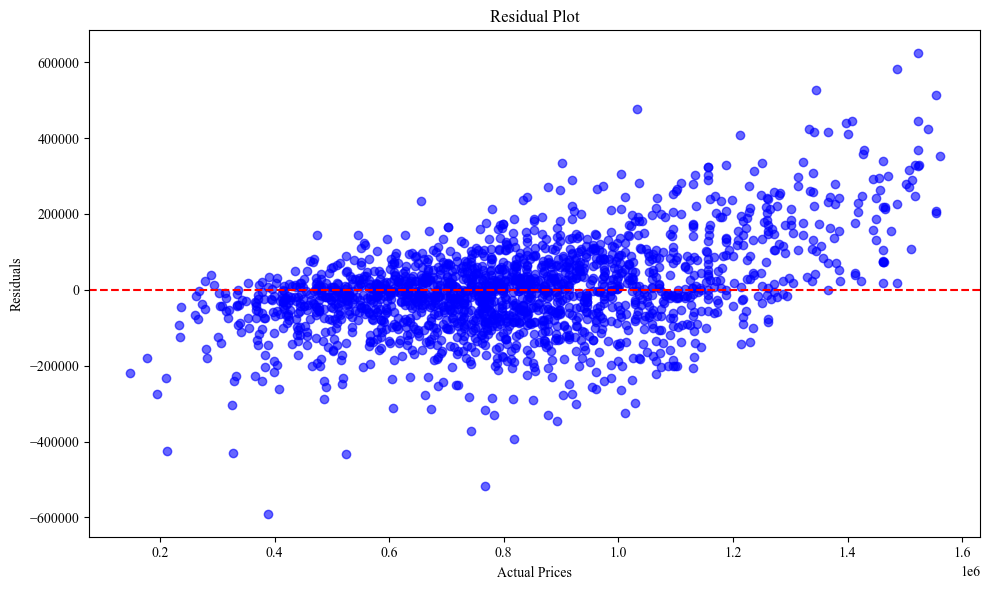

In [20]:
rf_regressor = RandomForestRegressor(n_estimators=28,random_state=42)
rf_regressor.fit(X_train,y_train)
rf_regressor.score(X_test,y_test)
rf_pred =rf_regressor.predict(X_test)
rf_score=rf_regressor.score(X_test,y_test)
expl_rf = explained_variance_score(rf_pred,y_test)

# Residual Plot
residuals = y_test - rf_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.6, color='b')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

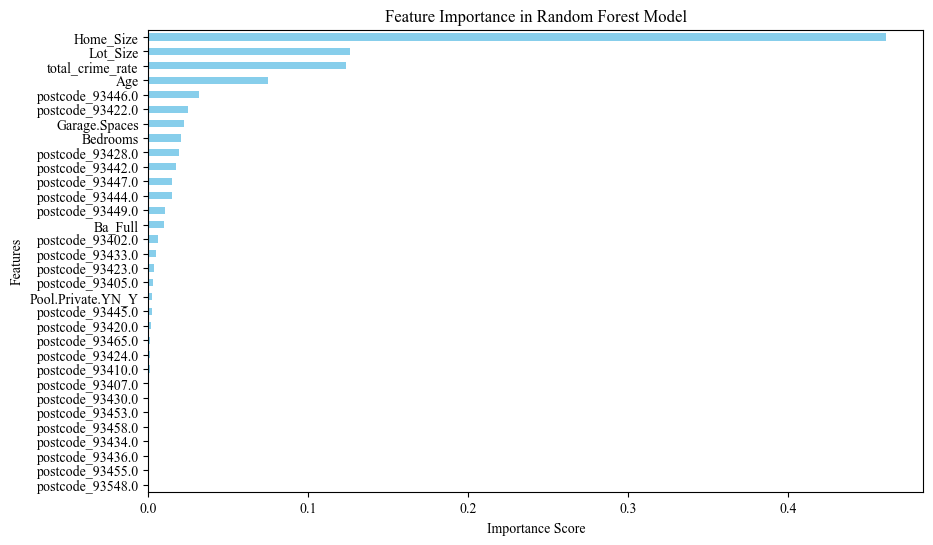

In [21]:
# Initialize and train the Random Forest model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Feature Importance
feature_importances = pd.Series(rf_regressor.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False)  # Sort by importance

# Plot the feature importances
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='skyblue')
plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()


# Final Version

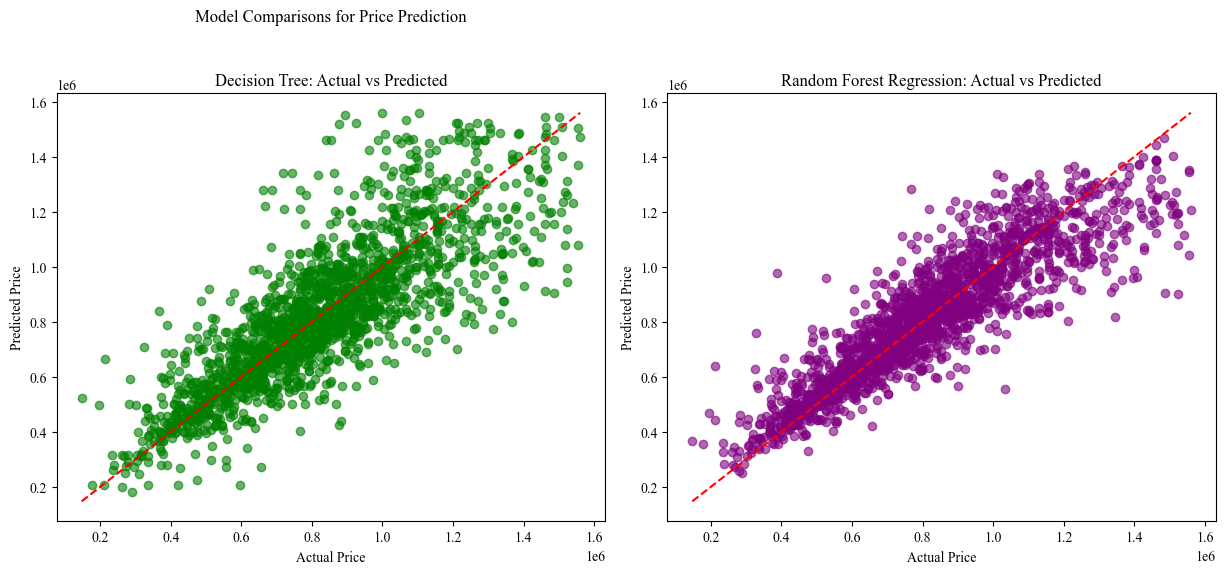

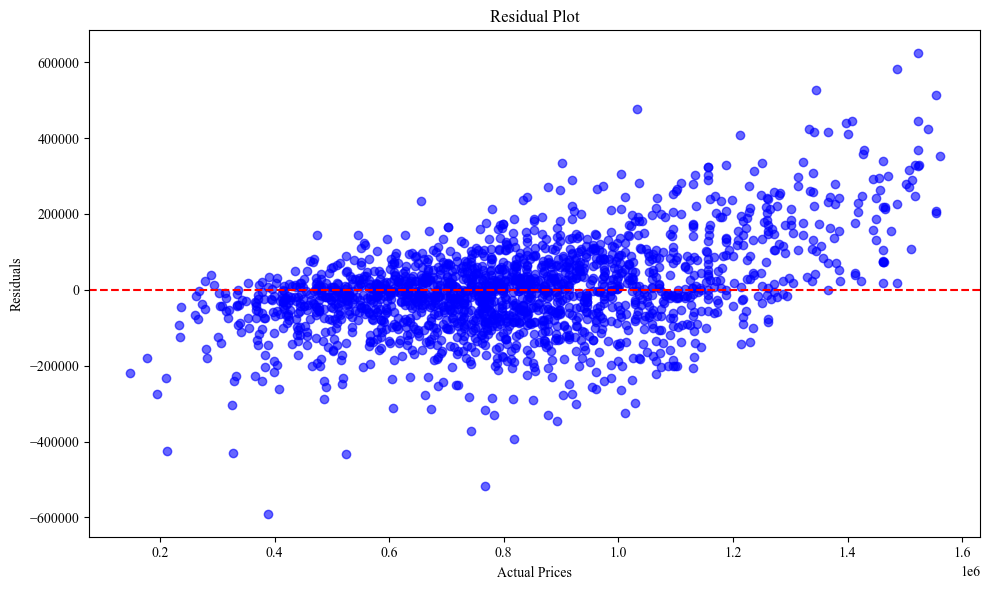

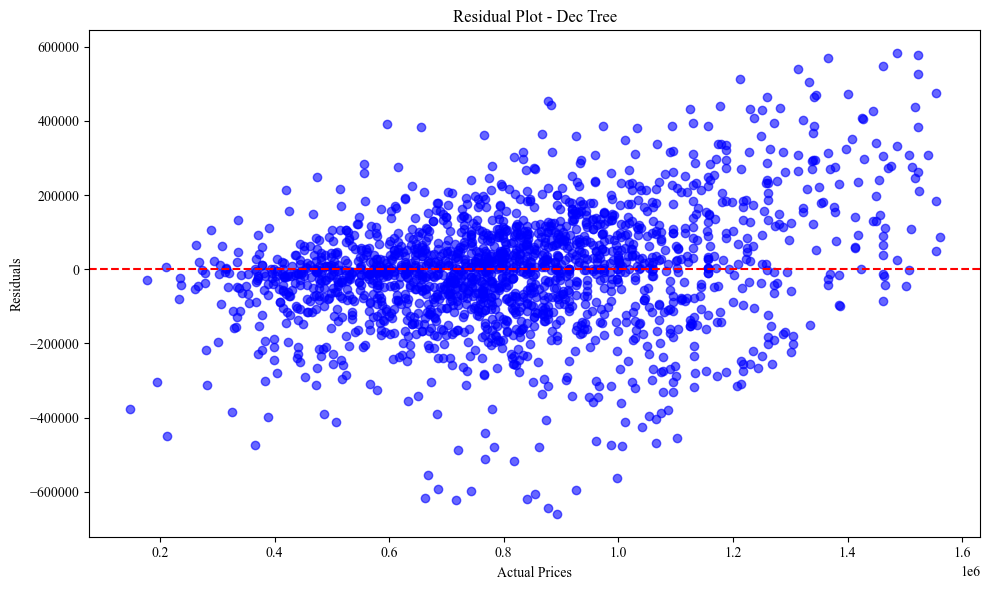

In [22]:
# Predictions for each model
#y_pred_mlr = mlr.predict(X_test)           # Multiple Linear Regression predictions
#y_pred_tree = tr_regressor.predict(X_test)  # Decision Tree predictions
y#_pred_rf = rf_regressor.predict(X_test)    # Random Forest predictions

# Set up the figure and axes for subplots
plt.figure(figsize=(18, 6))

""" 
# Multiple Linear Regression
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_mlr, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Ideal line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Multiple Linear Regression: Actual vs Predicted')
"""


# Decision Tree Regression
plt.subplot(1, 3, 2)
plt.scatter(y_test, pred_tr, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Ideal line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Decision Tree: Actual vs Predicted')



# Random Forest Regression
plt.subplot(1, 3, 3)
plt.scatter(y_test, rf_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Ideal line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest Regression: Actual vs Predicted')

# Show the plots
plt.suptitle('Model Comparisons for Price Prediction')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Residual Plot
residuals = y_test - rf_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.6, color='b')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

# Residual Plot
residuals_dt = y_test - pred_tr
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals_dt, alpha=0.6, color='b')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot - Dec Tree')
plt.tight_layout()
plt.show()

In [ ]:
# Filter out the top 5% of Adjusted_Price values
price_threshold = df['Adjusted_Price'].quantile(0.95)
df_filtered = df[df['Adjusted_Price'] <= price_threshold]

# Calculate the median of Adjusted_Price after filtering
median_price = df_filtered['Adjusted_Price'].median()

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['Adjusted_Price'], bins=40, color='skyblue', edgecolor='black')
plt.axvline(median_price, color='red', linestyle='--', linewidth=2)

# Add a label for the median
plt.text(
    median_price *1.35,  # x position (at median)
    plt.ylim()[1] *0.96, 
    f"Median: ${median_price:,.0f}",  # formatted with dollar sign and comma
    color="red",
    ha="center"
)

# Add titles and labels
plt.title("Histogram of All Home Prices (Top 5% Prices Excluded)")
plt.xlabel("Adjusted Price ($)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

all_predictions = np.array([tree.predict(X_test) for tree in rf_regressor.estimators_])
prediction_variability = all_predictions.std(axis=0)

plt.figure(figsize=(10, 6))
plt.hist(prediction_variability, bins=20, color="purple", edgecolor="black")
plt.title("Prediction Variability Across Trees in Random Forest")
plt.xlabel("Standard Deviation of Predictions")
plt.ylabel("Frequency")
plt.show()



In [ ]:
cumulative_importance = feature_importances.sort_values(ascending=False).cumsum()
plt.figure(figsize=(10, 6))
cumulative_importance.plot(kind='line', marker='o')
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance")
plt.grid()
plt.show()


In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color="purple")
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()



In [ ]:
residuals = y_test - rf_pred
plt.figure(figsize=(10, 6))
plt.scatter(rf_pred, residuals, alpha=0.3, color="purple")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
# Calculate the median price
median_price = df['Adjusted_Price'].median()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Adjusted_Price'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(median_price, color='red', linestyle='--', linewidth=2)

# Label for the median
plt.text(
    median_price,  # x position (at median)
    plt.ylim()[1] * 0.9,  # y position (90% up the y-axis)
    f"Median: ${median_price:,.0f}",  # format median with a dollar sign and commas
    color="red",
    ha="center"
)

# Add titles and labels
plt.title("Histogram of Housing Prices")
plt.xlabel("Housing Price ($)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## New Random Forest using feature importance first

In [ ]:
print(df_filtered.columns)

Top 12 features:
 ['Home_Size', 'distance_to_coast', 'Lot_Size', 'dist_closest_middleschool', 'dist_downtown', 'Year_Built', 'dist_closest_highschool', 'dist_closest_elementary', 'Avg_High_Temp', 'Bedrooms', 'Garage.Spaces', 'Avg_Low_Temp']
Model R^2 score with top 12 features: 0.8163935768676046


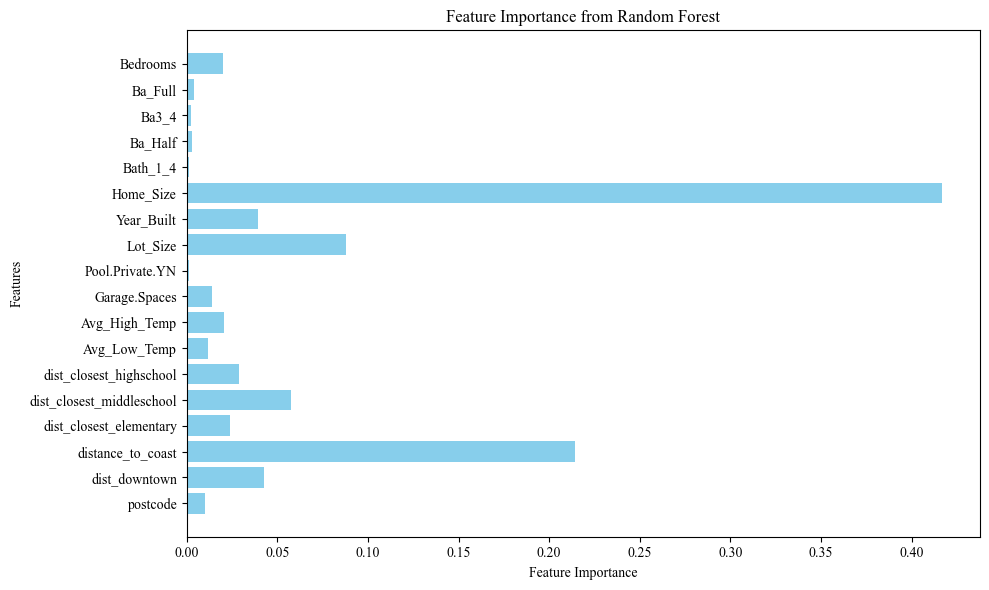

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd


n = 12  # Set the number of top features you want


# Step 1: Specify the columns you want to include
selected_columns = ['Bedrooms', 'Ba_Full', 'Ba3_4', 'Ba_Half', 'Bath_1_4', 'Home_Size', 'Year_Built', 
                    'Lot_Size', 'Pool.Private.YN', 'Garage.Spaces', 'Avg_High_Temp', 'Avg_Low_Temp', 
                 'dist_closest_highschool', 'dist_closest_middleschool', 'dist_closest_elementary', 
                    'distance_to_coast', 'dist_downtown', 'postcode']

# Step 2: Check for non-numeric columns and encode them
df_encoded = df_filtered.copy()
for col in selected_columns:
    if df_encoded[col].dtype == 'object' or isinstance(df_encoded[col].iloc[0], str):
        # Use LabelEncoder for simple encoding
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Subset the data using the selected columns
X = df_encoded[selected_columns]
y = df_encoded['Adjusted_Price']  # Replace 'target' with the name of your target variable

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Train a Random Forest model on the selected columns
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Step 5: Get feature importance
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

# Sort features by importance
top_features = feature_importances.sort_values(by='importance', ascending=False)

# Step 6: Select the top `n` features
top_n_features = top_features.head(n)['feature'].tolist()

# Display the top `n` features
print(f"Top {n} features:\n", top_n_features)

# Step 7: Subset the training and testing data with the top `n` features
X_train_top_n = X_train[top_n_features]
X_test_top_n = X_test[top_n_features]

# Step 8: Retrain the model with the top `n` features
rf_model_top_n = RandomForestRegressor(random_state=42)
rf_model_top_n.fit(X_train_top_n, y_train)

# Evaluate the model
score = rf_model_top_n.score(X_test_top_n, y_test)
print(f"Model R^2 score with top {n} features: {score}")

# Step 6: Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'], color='skyblue')
plt.gca().invert_yaxis()  # Highest importance on top
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Step 1: Preprocess data (ensure all features are numeric as shown in the previous code)
# Assuming `df_encoded` is already preprocessed
X = df_encoded[selected_columns]
y = df_encoded['Adjusted_Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 2: Train a Random Forest model and rank features by importance
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# List features ranked by importance
ranked_features = feature_importances['feature'].tolist()

# Step 3: Iteratively evaluate R^2 for top `k` features
results = []
for k in range(1, len(ranked_features) + 1):
    # Use top `k` features
    top_k_features = ranked_features[:k]
    X_train_k = X_train[top_k_features]
    X_test_k = X_test[top_k_features]
    
    # Train model with top `k` features
    rf_model_k = RandomForestRegressor(random_state=42)
    rf_model_k.fit(X_train_k, y_train)
    
    # Evaluate R^2
    r2_score = rf_model_k.score(X_test_k, y_test)
    results.append((k, r2_score))

# Step 4: Identify the optimal number of features
optimal_k, best_r2 = max(results, key=lambda x: x[1])

# Display the results
print(f"Optimal number of features: {optimal_k}")
print(f"Highest R^2 score: {best_r2}")

# Get the top features corresponding to the optimal `k`
optimal_features = ranked_features[:optimal_k]
print(f"Optimal features: {optimal_features}")


### Model Scores

In [ ]:
print("Multiple Linear Regression Model Score is ",round(mlr.score(X_test,y_test)*100))
print("Decision tree  Regression Model Score is ",round(tr_regressor.score(X_test,y_test)*100))
print("Random Forest Regression Model Score is ",round(rf_regressor.score(X_test,y_test)*100))

#Let's have a tabular pandas data frame, for a clear comparison

models_score =pd.DataFrame({'Model':['Multiple Linear Regression','Decision Tree','Random forest Regression'],
                            'Score':[mlr_score,decision_score,rf_score],
                            'Explained Variance Score':[expl_mlr,expl_tr,expl_rf]
                           })
models_score.sort_values(by='Score',ascending=False)

# New Random forest

In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("Checking for infinite or NaN values in X_train, X_test, y_train, y_test")
print(np.any(np.isinf(X_train)), np.any(np.isnan(X_train)))
print(np.any(np.isinf(X_test)), np.any(np.isnan(X_test)))
print(np.any(np.isinf(y_train)), np.any(np.isnan(y_train)))
print(np.any(np.isinf(y_test)), np.any(np.isnan(y_test)))


print(f"Min y_train: {y_train.min()}, Min y_test: {y_test.min()}")
print("Checking for invalid values in predictions")
print(np.any(np.isinf(rf_pred)), np.any(np.isnan(rf_pred)))


In [ ]:
# Assign weights to higher-value properties to help model focus on high-value cases
#weights = np.where(y_train > y_train.median(), 3, 1)

# Define the Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)

# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(rf_regressor, param_distributions=param_dist, n_iter=50, cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

# Best estimator
best_rf = random_search.best_estimator_

# Cross-Validation
from sklearn.model_selection import cross_val_score
cross_val_r2_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
cross_val_mean_r2 = np.mean(cross_val_r2_scores)
print(f"Cross-Validation R^2 Scores: {cross_val_r2_scores}")
print(f"Mean Cross-Validation R^2 Score: {cross_val_mean_r2}")


# Cross-Validation R^2 Scores Plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(cross_val_r2_scores) + 1), cross_val_r2_scores, color='skyblue')
plt.xlabel('Fold Number')
plt.ylabel('R^2 Score')
plt.title('Cross-Validation R^2 Scores Across Folds')
plt.tight_layout()
plt.show()

# Make predictions
rf_pred = best_rf.predict(X_test)

# Evaluate model performance
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
explained_var = explained_variance_score(y_test, rf_pred)

# Comparison of Cross-Validation vs Test R^2
plt.figure(figsize=(8, 6))
bars = plt.bar(['Cross-Validation Mean', 'Test Set'], [cross_val_mean_r2, rf_r2], color=['lightgreen', 'salmon'])
plt.xlabel('Evaluation Type')
plt.ylabel('R^2 Score')
plt.title('Comparison of Cross-Validation Mean R^2 and Test Set R^2')
plt.tight_layout()
plt.show()

print(f"Optimized Random Forest R^2 Score: {rf_r2}")
print(f"Optimized Random Forest RMSE: {rf_rmse}")
print(f"Optimized Random Forest Explained Variance: {explained_var}")

In [ ]:
print("Best Parameters:", random_search.best_params_)


In [ ]:
# Feature importance
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh', color = 'skyblue')
plt.title('Top 10 Feature Importances - Improved Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()


# Residual Plot
residuals = y_test - rf_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.6, color='b')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()


In [ ]:
residuals = y_test - rf_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.6, color='b')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, rf_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Ideal line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

# Anotehr Attempt

In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
# Assuming df is the DataFrame containing your data

# Assuming 'df' is your full DataFrame and you want to filter outliers and define X and y

# Calculate Q1 (25th percentile) and Q3 (75th percentile) of the target variable (price)
Q1 = df['Adjusted_Price'].quantile(0.25)
Q3 = df['Adjusted_Price'].quantile(0.75)
IQR = Q3 - Q1

# Use a less strict multiplier for IQR
lower_bound = Q1 - 1.0 * IQR
upper_bound = Q3 + 1.0 * IQR

# Filter the DataFrame to exclude outliers in price
df_filtered = df[(df['Adjusted_Price'] >= lower_bound) & (df['Adjusted_Price'] <= upper_bound)]

# Define features (X) and target (y) using filtered DataFrame
X = df_filtered[['Lot_Size', 'Home_Size', 'Bedrooms', 'Ba_Full', 'Age', 'Pool.Private.YN', 'Garage.Spaces', 'total_crime_rate', 'postcode']]
y = df_filtered['Adjusted_Price']

# Apply log transformation to variables with diminishing returns
X['Log_Lot_Size'] = np.log1p(X['Lot_Size'])
X['Log_Home_Size'] = np.log1p(X['Home_Size'])

# Add square terms to capture potential nonlinear relationships
X['Lot_Size_Squared'] = X['Lot_Size'] ** 2
X['Home_Size_Squared'] = X['Home_Size'] ** 2

# Drop original features replaced by transformed versions
X = X.drop(columns=['Lot_Size', 'Home_Size'])

# Convert 'postcode' to string to treat it as a categorical variable
X['postcode'] = X['postcode'].astype(str)

# Convert categorical variables to numerical (one-hot encoding)
X = pd.get_dummies(X, columns=['Pool.Private.YN', 'postcode'], drop_first=True)

# Handle missing values by imputing with the mean
X = X.fillna(X.mean())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)

# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [20, 25, 30, None],  # Increased depth options
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(rf_regressor, param_distributions=param_dist, n_iter=50, cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

# Best estimator
best_rf = random_search.best_estimator_

# Make predictions
rf_pred = best_rf.predict(X_test)

# Evaluate model performance
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
explained_var = explained_variance_score(y_test, rf_pred)

print(f"Optimized Random Forest R^2 Score: {rf_r2}")
print(f"Optimized Random Forest RMSE: {rf_rmse}")
print(f"Optimized Random Forest Explained Variance: {explained_var}")

# Feature importance
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Residual Plot
residuals = y_test - rf_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.6, color='b')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()


# Segmented modeling test

In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
# Assuming df is the DataFrame containing your data

# Assuming 'df' is your full DataFrame and you want to filter outliers and define X and y

# Calculate Q1 (25th percentile) and Q3 (75th percentile) of the target variable (price)
Q1 = df['Adjusted_Price'].quantile(0.25)
Q3 = df['Adjusted_Price'].quantile(0.75)
IQR = Q3 - Q1

# Use a less strict multiplier for IQR
lower_bound = Q1 - 1.0 * IQR
upper_bound = Q3 + 1.0 * IQR

# Filter the DataFrame to exclude outliers in price
df_filtered = df[(df['Adjusted_Price'] >= lower_bound) & (df['Adjusted_Price'] <= upper_bound)]

# Define features (X) and target (y) using filtered DataFrame
X = df_filtered[['Lot_Size', 'Home_Size', 'Bedrooms', 'Ba_Full', 'Age', 'Pool.Private.YN', 'Garage.Spaces', 'total_crime_rate', 'postcode']]
y = df_filtered['Adjusted_Price']

# Convert 'postcode' to string to treat it as a categorical variable
#X['postcode'] = X['postcode'].astype(str)

# Convert categorical variables to numerical (one-hot encoding)
X = pd.get_dummies(X, columns=['Pool.Private.YN', 'postcode'], drop_first=True)

# Handle missing values by imputing with the mean
X = X.fillna(X.mean())

# Segment the dataset into low, medium, and high price ranges
low_price_threshold = df_filtered['Adjusted_Price'].quantile(0.33)
high_price_threshold = df_filtered['Adjusted_Price'].quantile(0.67)

low_price_data = df_filtered[df_filtered['Adjusted_Price'] <= low_price_threshold]
medium_price_data = df_filtered[(df_filtered['Adjusted_Price'] > low_price_threshold) & (df_filtered['Adjusted_Price'] <= high_price_threshold)]
high_price_data = df_filtered[df_filtered['Adjusted_Price'] > high_price_threshold]

# Function to train and evaluate a Random Forest model for a specific segment
def train_and_evaluate(segment_data, segment_name):
    X_segment = segment_data[['Lot_Size', 'Home_Size', 'Bedrooms', 'Ba_Full', 'Age', 'Pool.Private.YN', 'Garage.Spaces', 'total_crime_rate', 'postcode']]
    y_segment = segment_data['Adjusted_Price']

    X_segment['postcode'] = X_segment['postcode'].astype(str)
    X_segment = pd.get_dummies(X_segment, columns=['Pool.Private.YN', 'postcode'], drop_first=True)
    X_segment = X_segment.fillna(X_segment.mean())

    X_train, X_test, y_train, y_test = train_test_split(X_segment, y_segment, test_size=0.3, random_state=42)

    rf_regressor = RandomForestRegressor(random_state=42)
    param_dist = {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', None]
    }

    random_search = RandomizedSearchCV(rf_regressor, param_distributions=param_dist, n_iter=50, cv=3, random_state=42, n_jobs=-1)
    random_search.fit(X_train, y_train)

    best_rf = random_search.best_estimator_
    rf_pred = best_rf.predict(X_test)

    rf_r2 = r2_score(y_test, rf_pred)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    explained_var = explained_variance_score(y_test, rf_pred)

    print(f"Segment: {segment_name}")
    print(f"R^2 Score: {rf_r2}")
    print(f"RMSE: {rf_rmse}")
    print(f"Explained Variance: {explained_var}")

    # Residual Plot
    residuals = y_test - rf_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, residuals, alpha=0.6, color='b')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Actual Prices')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot for {segment_name} Segment')
    plt.tight_layout()
    plt.show()

# Train and evaluate for each segment
train_and_evaluate(low_price_data, 'Low Price')
train_and_evaluate(medium_price_data, 'Medium Price')
train_and_evaluate(high_price_data, 'High Price')


# Other

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Select features for clustering (e.g., property characteristics)
clustering_features = df[['Lot_Size', 'Home_Size', 'Bedrooms','Ba_Full', 'Age','total_crime_rate', 'Pool.Private.YN', 'Garage.Spaces']]
clustering_features = pd.get_dummies(clustering_features, columns=['Pool.Private.YN'], drop_first=True)
clustering_features = clustering_features.fillna(clustering_features.mean())



In [ ]:
# Standardize features
scaler = StandardScaler()
clustering_features_scaled = scaler.fit_transform(clustering_features)

# Set up KMeans with a chosen number of clusters, e.g., 3
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(clustering_features_scaled)

# Add cluster labels to the original DataFrame
df['Cluster'] = kmeans.labels_

# Display the counts of each cluster
print("Cluster counts:\n", df['Cluster'].value_counts())

# Optional: view cluster centers
print("Cluster Centers:\n", scaler.inverse_transform(kmeans.cluster_centers_))

In [ ]:
from sklearn.decomposition import PCA

# Perform PCA to reduce data to two dimensions
pca = PCA(n_components=6)
pca_features = pca.fit_transform(clustering_features_scaled)

# Plot the clusters in the 2D PCA space
plt.figure(figsize=(10, 6))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Cluster Visualization with PCA')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
# Predictions for each model
y_pred_mlr = mlr.predict(X_test)           # Multiple Linear Regression predictions
y_pred_tree = tr_regressor.predict(X_test)  # Decision Tree predictions
y_pred_rf = rf_regressor.predict(X_test)    # Random Forest predictions

# Set up the figure and axes for subplots
plt.figure(figsize=(18, 6))

""" 
# Multiple Linear Regression
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_mlr, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Ideal line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Multiple Linear Regression: Actual vs Predicted')
"""


# Decision Tree Regression
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_tree, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Ideal line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Decision Tree: Actual vs Predicted')

# Random Forest Regression
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Ideal line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest Regression: Actual vs Predicted')

# Show the plots
plt.suptitle('Model Comparisons for Price Prediction')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Generate predictions for each model
y_pred_mlr = mlr.predict(X_test)           # Multiple Linear Regression predictions
y_pred_tree = tr_regressor.predict(X_test)  # Decision Tree predictions
y_pred_rf = rf_regressor.predict(X_test)    # Random Forest predictions

# Sort values for a cleaner line plot (based on actual test values)
y_test_sorted = y_test.sort_index()
y_pred_mlr_sorted = pd.Series(y_pred_mlr, index=y_test.index).sort_index()
y_pred_tree_sorted = pd.Series(y_pred_tree, index=y_test.index).sort_index()
y_pred_rf_sorted = pd.Series(y_pred_rf, index=y_test.index).sort_index()

# Plotting
plt.figure(figsize=(15, 8))

# Actual prices
plt.plot(y_test_sorted.values, label='Actual Price', color='black', linewidth=2)

# Predicted prices by each model
plt.plot(y_pred_mlr_sorted.values, label='Multiple Linear Regression', linestyle='--', color='blue')
plt.plot(y_pred_tree_sorted.values, label='Decision Tree', linestyle='--', color='green')
plt.plot(y_pred_rf_sorted.values, label='Random Forest', linestyle='--', color='purple')

# Labels and title
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Generate predictions for each model
y_pred_mlr = mlr.predict(X_test)           # Multiple Linear Regression predictions
y_pred_tree = tr_regressor.predict(X_test)  # Decision Tree predictions
y_pred_rf = rf_regressor.predict(X_test)    # Random Forest predictions

# Sort values for a cleaner line plot (based on actual test values)
y_test_sorted = y_test.sort_index()
y_pred_mlr_sorted = pd.Series(y_pred_mlr, index=y_test.index).sort_index()
y_pred_tree_sorted = pd.Series(y_pred_tree, index=y_test.index).sort_index()
y_pred_rf_sorted = pd.Series(y_pred_rf, index=y_test.index).sort_index()

# Set up figure for 3 subplots
plt.figure(figsize=(18, 12))

# Plot for Multiple Linear Regression
plt.subplot(3, 1, 1)
plt.plot(y_test_sorted.values, label='Actual Price', color='black', linewidth=2)
plt.plot(y_pred_mlr_sorted.values, label='Predicted Price (MLR)', linestyle='--', color='blue')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Multiple Linear Regression: Actual vs Predicted Prices')
plt.legend()

# Plot for Decision Tree Regression
plt.subplot(3, 1, 2)
plt.plot(y_test_sorted.values, label='Actual Price', color='black', linewidth=2)
plt.plot(y_pred_tree_sorted.values, label='Predicted Price (Decision Tree)', linestyle='--', color='green')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Decision Tree: Actual vs Predicted Prices')
plt.legend()

# Plot for Random Forest Regression
plt.subplot(3, 1, 3)
plt.plot(y_test_sorted.values, label='Actual Price', color='black', linewidth=2)
plt.plot(y_pred_rf_sorted.values, label='Predicted Price (Random Forest)', linestyle='--', color='purple')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Random Forest Regression: Actual vs Predicted Prices')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


In [ ]:
%pip install xgboost


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import explained_variance_score

# Initialize the XGBoost Regressor with chosen hyperparameters
xgb_regressor = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)

# Fit the model on the training data
xgb_regressor.fit(X_train, y_train)

# Calculate the score (R^2) on the test data
xgb_score = xgb_regressor.score(X_test, y_test)

# Make predictions on the test set
xgb_pred = xgb_regressor.predict(X_test)

# Calculate explained variance score
expl_xgb = explained_variance_score(y_test, xgb_pred)

# Display the results
print("XGBoost R^2 Score:", xgb_score)
print("XGBoost Explained Variance Score:", expl_xgb)


# Regular Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Load and filter the dataset
#df_zip = pd.read_excel("/mnt/data/SLO_House_Price_ZipCode.xlsx")

# Filter relevant columns and drop rows with missing values
df_zip_filtered = df[
    [
        "Home_Size", "Lot_Size", "Year_Built", "CITY", "Bedrooms", "Ba_Full", 
        "Ba_Half", "Garage.Spaces", "Pool",
         "Avg_High_Temp", "Adjusted_Price"
    ]
].dropna()

# Feature Engineering
df_zip_filtered["Age"] = 2024 - df_zip_filtered["Year_Built"]

# One-hot encode categorical variables (CITY and House_Type) and drop the original columns
df_zip_encoded = pd.get_dummies(df_zip_filtered, columns=["CITY"], drop_first=True)

# Define independent variables (X) and dependent variable (y)
X = df_zip_encoded.drop(columns=["Year_Built", "Adjusted_Price"])
y = df_zip_encoded["Adjusted_Price"]

# Standardize numeric variables to address scale differences and improve model stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add a constant to the scaled variables for the OLS model
X_scaled = sm.add_constant(X_scaled)

# Fit the model using statsmodels for a detailed summary
model = sm.OLS(y, X_scaled).fit()
model_summary = model.summary()

# Display the model summary
model_summary


In [ ]:
%pip install folium

In [ ]:
#Read in the data
file_path = 'data/recent_sales_new.csv'
df_2 = pd.read_csv(file_path )
df_2.head()

In [ ]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd

# Center map on San Luis Obispo and initialize it
slo_map = folium.Map(location=[35.2828, -120.6596], zoom_start=12)

# Add a cluster layer for each property
marker_cluster = MarkerCluster().add_to(slo_map)

# Add markers to the map for each property
for idx, row in df_2.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Price: ${row['Adjusted_Price']}",
        tooltip="Click for more info"
    ).add_to(marker_cluster)

# Save the map as an HTML file or display it directly
slo_map.save("SLO_housing_map.html")
slo_map

In [ ]:
# Check for missing values in coordinate columns
print(df[['Latitude', 'Longitude', 'osm_lat', 'osm_lon']].isnull().sum())

# Preview the unique values to see if they’re all the same or defaulting to a specific location
# Check the unique values in Latitude and Longitude
print("Unique values for Latitude:", df['Latitude'].unique())
print("Unique values for Longitude:", df['Longitude'].unique())
